# 

# Машинное обучение. ВМК МГУ

# Практическое задание 10: Градиентный бустинг деревьев - часть 1

## Уровень: <font color='SkyBlue'>**Базовый (Base)**</font>

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

-----------
<font color="white" style="opacity:0.2025"></font>







__В этом задании вы..:__

- Познакомитесь с несколькими новыми библиотеками машинного обучения
- Сравните между собой разные реализации градиентных бустингов

----

<font color="white" style="opacity:0.2025"></font>
<font color=DarkOrange>**Примерное время выполнения (execution time/время выполнения, если нажать run all) всех ячеек ноутбука при правильной реализации: не более 60 минут </font>**

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, **возможно,** нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится


На скачивание файла и установку понадобится не более 5 минут.

<font color='OrangeRed'>**Важно!**</font>

Устанавливать нужные версии нужно каждый раз, когда создается новый рантайм. Например, если вы 2 часа подряд делаете это задание, то подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в понедельник, затем закрыли/выключили ноутбук, то при продолжении в среду, вам нужно будет запустить рантайм заново и следовательно заново установить библиотеки.

<font color='OrangeRed'>**Важно!**</font>
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в [соответствии с гайдом](https://github.com/MSU-ML-COURSE/ML-COURSE-24-25/blob/main/tutorials/%D0%A2%D1%83%D1%82%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%20%D0%BF%D0%BE%20%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5%20%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE%20%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B2%20Python%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20(2).pdf)


In [1]:
! pip install -q -r ./requirements_2025_26_for_colab_small.txt

In [2]:
import catboost
assert(catboost.__version__ == '1.2.8')

Теперь можно приступать к выполнению задания! :)

-----------
<font color="white" style="opacity:0.2025"></font>




## Введение

Сегодня мы с вами будем решать очень важную задачу, а именно оценивать цену поддержанных автомобилей в ряде стран. Делать мы это будем с помощью различных методов градиентного бустинга. Мы с вами узнаем, что в мире существует не только sklearn, и что существуют библиотеки, облегчающие нам задачу поиска оптимальных параметров для моделей.

<font color='OrangeRed'>**Внимание!**</font> Во всех заданиях в качестве целевой метрики используется MAE (средняя абсолютная ошибка).

Значение MAE вычисляется как

$$
  MAE = \sum_{i = 1}^N\dfrac{|a(x_i) - y_i|}{N},
$$

где $N$ - число объектов в тестовой выборке, $x_i$ - вектор признаков i-го объекта, $a(x_i)$ - предсказание на i-ом объекте, $y_i$ - значение целевого признака на i-м объекте.

## Установка дополнительных библиотек.

В этом задании нам понадобятся три бибиотеки, которыми вы ранее не пользовались в этом курсе, а именно:

<font color='plum'>**XGBoost**:</font> Документация [здесь](https://xgboost.readthedocs.io/en/stable/).<br />
<font color='plum'>**LightGBM**:</font> Документация [здесь](https://lightgbm.readthedocs.io/en/latest/index.html). Также дополнительно про установку [тут](https://pypi.org/project/lightgbm/).<br />
<font color='plum'>**Catboost**:</font> Документация [здесь](https://catboost.ai/en/docs/). Можно найти также некоторую информацию на русском [тут](https://habr.com/ru/company/otus/blog/527554/).<br />
<font color='plum'>**HyperOpt**:</font> Документация [здесь](http://hyperopt.github.io/hyperopt/). <br />


<font color='OrangeRed'>**Внимание!**</font> Вникать и подробно читать документацию к каждой библиотеке нет необходимости! Достаточно обращаться туда для нахождения примеров обучения.


## Подготовка датасета

Все библиотеки, используемые сегодня, мы будем проверять на одних и тех же параметрах:

```n_estimators=1000, max_depth=5, learning_rate=0.1.```

Таким образом мы устанавливаем, соответственно, число деревьев в ансамбле равным 1000, ограничиваем максимальную глубину деревьев 5 и устанавливаем темп обучения равным 0.1. Создадим сразу словарь, чтобы передавать эти параметры создаваемым регрессорам (если вдруг не знали, словарь можно передавать как параметры, поставив перед ним **).

Эти параметры мы вынесем в отдельную переменную `test_parameters`.

При желании можно почитать про этот датасет на платформе kaggle: [ссылка на данные](https://www.kaggle.com/bushnag/cars-in-the-middle-east?select=dataframe_YesIndex_YesHeader_C.csv). <span style="color:red"> <font color="OrangeRed">Не скачивайте датасет из kaggle для выполнения ноутбука, поскольку его могут изменить.</font></span> Нас интересует файл dataframe_YesIndex_YesHeader_C.csv, поскольку он уже хорошо предобработан (хотя, конечно, датасаентисты должны сами уметь это делать, но ладно).
Давайте попробуем загрузить датасет в память и посмотреть, как он выглядит.

При работе в google colab для скачивания датасета достаточно запустить следующую ячейку.

При работе с ноутбуком <span style="color:red"> <font color="OrangeRed">на локальном компьютере</font></span> Вы можете скачать файл по [этой ссылке](https://drive.google.com/file/d/1gdDv2kTCEkF3ia1vvbvRFJM0YfqmPplb/view?usp=sharing) и чуть ниже заменить ` /content/dataframe_YesIndex_YesHeader_C.csv` (в строке с `read_csv`) на ваш локальный путь до файла.

In [3]:
! pip install -q -r ./requirements_2025_26_for_colab_small.txt

In [4]:
%matplotlib inline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, make_scorer

from hyperopt import hp, tpe, Trials
from hyperopt.fmin import fmin
from hyperopt.pyll import scope

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

from catboost import CatBoostRegressor

import matplotlib.pyplot as plt

import pandas as pd

import numpy as np

import time

Matplotlib is building the font cache; this may take a moment.
c:\Users\glebl\anaconda3\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [5]:
test_parameters = {"n_estimators": 1000, "max_depth": 5, "learning_rate":0.1}

df = pd.read_csv('dataframe_YesIndex_YesHeader_C.csv', index_col=0)
df.head()

,Engine Capacity,Cylinders,Drive Type,Fuel Tank Capacity,Fuel Economy,Fuel Type,Horsepower,Torque,Transmission,Top Speed,...,Acceleration,Length,Width,Height,Wheelbase,Trunk Capacity,name,price,currency,Country
0,1.2,3,0,42.0,4.9,0,76,100.0,0,170,...,14.0,4.245,1.670,1.515,2.550,450.0,Mitsubishi Attrage 2021 1.2 GLX (Base),34099.0,0,0
1,1.2,3,0,42.0,4.9,0,76,100.0,0,170,...,14.0,4.245,1.670,1.515,2.550,450.0,Mitsubishi Attrage 2021 1.2 GLX (Base),34099.0,0,0
2,1.4,4,0,45.0,6.3,0,75,118.0,1,156,...,16.0,3.864,1.716,1.721,2.513,2800.0,Fiat Fiorino 2021 1.4L Standard,41250.0,0,0
3,1.6,4,0,50.0,6.4,0,102,145.0,0,180,...,11.0,4.354,1.994,1.529,2.635,510.0,Renault Symbol 2021 1.6L PE,44930.0,0,0
4,1.5,4,0,48.0,5.8,0,112,150.0,0,170,...,10.9,4.314,1.809,1.624,2.585,448.0,MG ZS 2021 1.5L STD,57787.0,0,0


### <font color='DarkOrange'>**Задание 0 [без проверки, 0 баллов]**</font>

Посмотрите на цены автомобилей. Попробуйте понять, написаны они в одной валюте или нет. Если нет -- будут ли у нас серьезные проблемы при использовании деревьев? Стоит ли нам что-то сделать для того, чтобы нивелировать эту проблему?


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4560 entries, 0 to 5667
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Engine Capacity     4560 non-null   float64
 1   Cylinders           4560 non-null   int64  
 2   Drive Type          4560 non-null   int64  
 3   Fuel Tank Capacity  4560 non-null   float64
 4   Fuel Economy        4560 non-null   float64
 5   Fuel Type           4560 non-null   int64  
 6   Horsepower          4560 non-null   int64  
 7   Torque              4560 non-null   float64
 8   Transmission        4560 non-null   int64  
 9   Top Speed           4560 non-null   int64  
 10  Seating Capacity    4560 non-null   int64  
 11  Acceleration        4560 non-null   float64
 12  Length              4560 non-null   float64
 13  Width               4560 non-null   float64
 14  Height              4560 non-null   float64
 15  Wheelbase           4560 non-null   float64
 16  Trunk Capac

In [7]:
quantiles = (
    df.groupby('Country')['price']
      .quantile([0.25, 0.50, 0.75])
      .unstack(level=1)
      .rename(columns={0.25: 'q25', 0.50: 'q50', 0.75: 'q75'})
)
quantiles

,q25,q50,q75
Country,,,
0,114989.0,192500.0,351797.0
1,99900.0,174000.0,317150.0
2,109000.0,197250.0,350850.0
3,8400.0,14950.0,25990.0
4,13000.0,21500.0,37925.0
5,10500.0,18600.0,32900.0


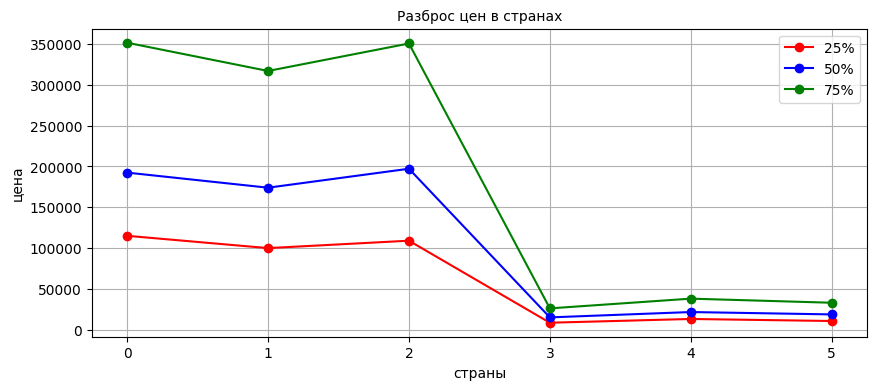

In [8]:
# задаем размеры
plt.figure(figsize=(10,4))

# заголовок
plt.title('Разброс цен в странах', fontsize=10)

# рисуем графики
plt.plot(quantiles.index, quantiles.iloc[:, 0], marker='o', color='r', label = '25%')
plt.plot(quantiles.index, quantiles.iloc[:, 1], marker='o', color='b', label = '50%')
plt.plot(quantiles.index, quantiles.iloc[:, 2], marker='o', color='g', label = '75%')

# x_vals - значения по оси x
# y_vals - значения по оси y
# linestyle: '--' - dashed line style, '-.'- dash-dot line style, ...
# color: r, g, b, ...
# marker: '.', 'o', '+', ...

# сетка графика
plt.grid(True, "both", "both")

# разметка осей
# plt.xticks([math.pi * x for x in range(-3, 4)], ["-3$\pi$", "-2$\pi$", "-$\pi$", "0", "$\pi$", "2$\pi$", "3$\pi$"])
# plt.yticks(range(-2, 3))

# подписи осей
plt.ylabel('цена',  fontsize=10)
plt.xlabel('страны',  fontsize=10)

# легенда
plt.legend(fontsize=10)

plt.show()

In [9]:
df1 = df.groupby('name').apply(
    lambda g: pd.Series({
        'price_unique': g['price'].unique().tolist(),
        'country_unique': g['Country'].unique().tolist()
    })
)
df1

C:\Users\glebl\AppData\Local\Temp\ipykernel_11936\4236281999.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df.groupby('name').apply(


,price_unique,country_unique
name,,
Abarth 124 Spider 2021 1.4T (170 HP),[140000.0],[1]
Abarth 595 2021 1.4T Competizione (Convertible),[120000.0],[1]
Abarth 595 2021 1.4T Competizione (Hard-Top),[110000.0],[1]
Abarth 695 2021 1.4T Rivale (Convertible),[130000.0],[1]
Abarth 695 2021 1.4T Rivale (Hard-Top),[120000.0],[1]
...,...,...
Volvo XC90 2021 2.0T T5 AWD Momentum,"[273900.0, 224900.0, 23500.0, 239900.0]","[0, 1, 4, 2]"
Volvo XC90 2021 2.0T T5 AWD R Design,"[306900.0, 239900.0, 24900.0]","[0, 1, 4]"
Volvo XC90 2021 2.0T T6 AWD R Design,"[334400.0, 269900.0, 21000.0, 27000.0, 294900.0]","[0, 1, 3, 4, 2]"


----

В глаза бросаются две проблемы: у нас имеется информация о производителе автомобиля, скрытая в текстовой переменной модели автомобиля (нет отдельного признака). Также имеются некоторые категориальные переменные. Со всем этим безобразием надо что-то сделать.


### <font color='DarkOrange'>**Задание 1 [2 балла]**</font>

**Данные**: датасет со стоимостью подержанных автомобилей  
**Цели**: В данном задании следует выполнить следующие пункты:
1. Изучить датасет, проверить наличие `пропусков.` Под пропусками подразумевается значение N/A вместо признака. При необходимости заменить их на среднее значение признака.
3. Добавить `столбец brand` с информацией о производителе автомобиля (для простоты можно взять первое слово в названии модели).
4. Решить, какие признаки Вы считаете `категориальными.` Конвертировать выбранные категориальные столбцы в тип category.
5. Создать `датасет А`, в котором выбранные категориальные признаки установлены как категориальные. Для этого необходимо создать вектор целевых значений Y (столбец цен автомобилей) и матрицу признаков X, в которой все категориальные переменные помечены как .astype('category'). Дополнительно стоит создать список с названиями и индексами столбцов категориальных переменных (поможет в будущем).
6. Создать `датасет B` без категориальных признаков. Для этого необходимо просто удалить из матрицы признаков все категориальные переменные.
7. Создать `датасет C`, в котором выбранные категориальные признаки закодированы через one-hot encoding. Для этого необходимо из матрицы признаков удалить выбранные категориальные переменные, а затем добавить новые признаки, соответствующие one-hot encoding этих категориальных переменных (со всей этой магией поможет простая функция `pd.get_dummies`).
8. Разбить датасеты на `тренировочное и тестовое множества`, используя `train_test_split(X, y, test_size=0.25, random_state=0)` (зафиксировав random_seed мы получим одинаковое разбиение на обучение/тест для всех трёх выборок).


In [10]:
datasets = {'A' : None, 'B': None, 'C': None}

df = pd.read_csv('dataframe_YesIndex_YesHeader_C.csv', index_col=0)
df_number = df.select_dtypes(include='number')
df_not_na = df_number.fillna(df_number.mean())
df_not_na['brand_1'] = df['name'].str.split().str[0]
df_not_na['brand_2'] = df['name'].str.split().str[1]
df_not_na

,Engine Capacity,Cylinders,Drive Type,Fuel Tank Capacity,Fuel Economy,Fuel Type,Horsepower,Torque,Transmission,Top Speed,...,Length,Width,Height,Wheelbase,Trunk Capacity,price,currency,Country,brand_1,brand_2
0,1.2,3,0,42.0,4.9,0,76,100.0,0,170,...,4.245,1.670,1.515,2.550,450.0,34099.0,0,0,Mitsubishi,Attrage
1,1.2,3,0,42.0,4.9,0,76,100.0,0,170,...,4.245,1.670,1.515,2.550,450.0,34099.0,0,0,Mitsubishi,Attrage
2,1.4,4,0,45.0,6.3,0,75,118.0,1,156,...,3.864,1.716,1.721,2.513,2800.0,41250.0,0,0,Fiat,Fiorino
3,1.6,4,0,50.0,6.4,0,102,145.0,0,180,...,4.354,1.994,1.529,2.635,510.0,44930.0,0,0,Renault,Symbol
4,1.5,4,0,48.0,5.8,0,112,150.0,0,170,...,4.314,1.809,1.624,2.585,448.0,57787.0,0,0,MG,ZS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5662,6.6,12,2,82.0,14.1,0,563,820.0,0,250,...,5.285,1.947,1.502,3.112,283.0,1300000.0,2,2,Rolls,Royce
5663,6.8,8,2,96.0,15.0,0,530,1100.0,0,305,...,5.575,1.926,1.521,3.266,443.0,1600000.0,2,2,Bentley,Mulsanne
5664,6.7,12,2,100.0,14.8,0,563,900.0,0,250,...,5.762,2.018,1.646,3.552,548.0,1950000.0,2,2,Rolls,Royce
5665,6.5,12,1,90.0,16.0,0,770,720.0,0,350,...,4.343,2.098,1.136,2.700,140.0,1850000.0,2,2,Lamborghini,Aventador


In [11]:
print(df_not_na['Cylinders'].unique())
print(df_not_na['Drive Type'].unique())
print(df_not_na['Fuel Type'].unique())
print(df_not_na['Transmission'].unique())
print(df_not_na['Seating Capacity'].unique())
print(df_not_na['currency'].unique())
print(df_not_na['Country'].unique())
# Преобразуем все 7 столбцов в категориальный признак
df_not_na['Cylinders'] = df_not_na['Cylinders'].astype('category')
df_not_na['Drive Type'] = df_not_na['Drive Type'].astype('category')
df_not_na['Fuel Type'] = df_not_na['Fuel Type'].astype('category')
df_not_na['Transmission'] = df_not_na['Transmission'].astype('category')
df_not_na['Seating Capacity'] = df_not_na['Seating Capacity'].astype('category')
df_not_na['currency'] = df_not_na['currency'].astype('category')
df_not_na['Country'] = df_not_na['Country'].astype('category')
df_not_na['brand_1'] = df_not_na['brand_1'].astype('category')
df_not_na['brand_2'] = df_not_na['brand_2'].astype('category')
df_not_na = df_not_na.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df_not_na.columns = df_not_na.columns.str.strip()
df_not_na.info()

[ 3  4  6  5  8 12 16 10]
[0 1 2]
[0 1 2]
[0 1 2]
[5 2 7 4 3 6 8 9]
[0 1 5 3 4 2]
[0 1 5 3 4 2]
<class 'pandas.core.frame.DataFrame'>
Index: 4560 entries, 0 to 5667
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Engine Capacity     4560 non-null   float64 
 1   Cylinders           4560 non-null   category
 2   Drive Type          4560 non-null   category
 3   Fuel Tank Capacity  4560 non-null   float64 
 4   Fuel Economy        4560 non-null   float64 
 5   Fuel Type           4560 non-null   category
 6   Horsepower          4560 non-null   int64   
 7   Torque              4560 non-null   float64 
 8   Transmission        4560 non-null   category
 9   Top Speed           4560 non-null   int64   
 10  Seating Capacity    4560 non-null   category
 11  Acceleration        4560 non-null   float64 
 12  Length              4560 non-null   float64 
 13  Width               4560 non-null   float64 
 1

In [12]:
df_not_na

,Engine Capacity,Cylinders,Drive Type,Fuel Tank Capacity,Fuel Economy,Fuel Type,Horsepower,Torque,Transmission,Top Speed,...,Length,Width,Height,Wheelbase,Trunk Capacity,price,currency,Country,brand_1,brand_2
0,1.2,3,0,42.0,4.9,0,76,100.0,0,170,...,4.245,1.670,1.515,2.550,450.0,34099.0,0,0,Mitsubishi,Attrage
1,1.2,3,0,42.0,4.9,0,76,100.0,0,170,...,4.245,1.670,1.515,2.550,450.0,34099.0,0,0,Mitsubishi,Attrage
2,1.4,4,0,45.0,6.3,0,75,118.0,1,156,...,3.864,1.716,1.721,2.513,2800.0,41250.0,0,0,Fiat,Fiorino
3,1.6,4,0,50.0,6.4,0,102,145.0,0,180,...,4.354,1.994,1.529,2.635,510.0,44930.0,0,0,Renault,Symbol
4,1.5,4,0,48.0,5.8,0,112,150.0,0,170,...,4.314,1.809,1.624,2.585,448.0,57787.0,0,0,MG,ZS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5662,6.6,12,2,82.0,14.1,0,563,820.0,0,250,...,5.285,1.947,1.502,3.112,283.0,1300000.0,2,2,Rolls,Royce
5663,6.8,8,2,96.0,15.0,0,530,1100.0,0,305,...,5.575,1.926,1.521,3.266,443.0,1600000.0,2,2,Bentley,Mulsanne
5664,6.7,12,2,100.0,14.8,0,563,900.0,0,250,...,5.762,2.018,1.646,3.552,548.0,1950000.0,2,2,Rolls,Royce
5665,6.5,12,1,90.0,16.0,0,770,720.0,0,350,...,4.343,2.098,1.136,2.700,140.0,1850000.0,2,2,Lamborghini,Aventador


In [13]:
Y = df_not_na['price']
X = df_not_na.drop('price', axis=1)
A = X.copy()
Category_columns_A = A.select_dtypes(include='category').columns.tolist()
Category_columns_indices_A = [A.columns.get_loc(col) for col in Category_columns_A]
B = X.select_dtypes(exclude='category')
categorical_ohe = pd.get_dummies(A[Category_columns_A], dtype=float)
C = pd.concat([B, categorical_ohe], axis=1)
X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(A, Y, test_size=0.25, random_state=0)
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(B, Y, test_size=0.25, random_state=0)
X_C_train, X_C_test, y_C_train, y_C_test = train_test_split(C, Y, test_size=0.25, random_state=0)

Итак, кажется, что у нас всё готово для того, чтобы начать искать ответы на волнующие нас вопросы. Начнем со столь любимой нами библиотеки, а именно...

## Градиентный бустинг со sklearn

Естественно, в `sklearn` имеется реализация градиентного бустинга, которая хранится в `sklearn.ensemble.GradientBoostingRegressor`. Преимущественно данным классом пользуются в учебных заданиях, а в реальных задачах предпочтение отдаётся другим библиотекам. Давайте попробуем понять, заслуженно ли градиентный бустинг в sklearn не пользуется популярностью.

FYI: в sklearn имеется также реализация `GradientBoostingClassifier` для задач классификации, но пользоваться им мы сегодня не будем.

`GradientBoostingRegressor` из коробки не умеет работать с категориальными признаками. Мы к этому уже подготовились, закодировав наши признаки.



### <font color='DarkOrange'>**Задание 2 [1.5 баллa]**</font>

**Данные**: датасет со стоимостью поддержанных автомобилей    
**Метрика**: MAE    
**Цели**: В данном задании следует выполнить следующие пункты:    
1. Обучить `sklearn.ensemble.GradientBoostingRegressor` на `датасетах B и C `(получится два разных регрессора), используя параметры `n_estimators=1000, max_depth=5, learning_rate=0.1` (наши `test_parameters`). Замерить время обучения.
2. Посчитать `MAE` для предсказаний на соответствующих тренировочном и тестовом множествах (можно воспользоваться sklearn.metrics.mean_absolute_error). Замерить время предсказания.
3. Вывести в `таблице DataFrame` результаты о времени обучения, времени предсказания, MAE на тренировочном и тестовом множествах.
<font color='red'>**Внимание!**</font> Для каждого из последующих заданий создавайте новые переменные для таблиц DataFrame - в задании 6 необходимо будет объединить все полученные результаты
4. `Сделайте выводы.` Оцените полезность категориальных переменных. Оцените время, затраченное на обучение. Попробуйте дать оценку получившемуся MAE: оно большое или маленькое?


In [14]:
df_skl = pd.DataFrame(columns=['Dataset', 'Training time', 'Prediction time', 'Train MAE', 'Test MAE'])

df_skl2 = df_skl.copy()

GBR_B = GradientBoostingRegressor(**test_parameters)
time_start = time.time()
GBR_B.fit(X_B_train, y_B_train)
time_end = time.time()
training_time = time_end - time_start
print(f"Время обучения на датасете B: {training_time} секунд")
y_B_train_pred = GBR_B.predict(X_B_train)
time_start = time.time()
y_B_test_pred = GBR_B.predict(X_B_test)
time_end = time.time()
prediction_time = time_end - time_start
print(f"Время предсказания на датасете B: {prediction_time} секунд")
train_mae = mean_absolute_error(y_B_train, y_B_train_pred)
test_mae = mean_absolute_error(y_B_test, y_B_test_pred)
print(f"MAE на обучающей выборке для датасета B: {train_mae}")
print(f"MAE на тестовой выборке для датасета B: {test_mae}")

#df_skl2 = df_skl2.append({'Dataset': 'B', 'Training time': training_time, 'Prediction time': prediction_time, 'Train MAE': train_mae, 'Test MAE': test_mae}, ignore_index=True)
df_skl2.loc[len(df_skl2)] = ['B', training_time, prediction_time, train_mae, test_mae]

GBR_C = GradientBoostingRegressor(**test_parameters)
time_start = time.time()
GBR_C.fit(X_C_train, y_C_train)
time_end = time.time()
training_time = time_end - time_start
print(f"Время обучения на датасете C: {training_time} секунд")
y_C_train_pred = GBR_C.predict(X_C_train)
time_start = time.time()
y_C_test_pred = GBR_C.predict(X_C_test)
time_end = time.time()
prediction_time = time_end - time_start
print(f"Время предсказания на датасете C: {prediction_time} секунд")
train_mae = mean_absolute_error(y_C_train, y_C_train_pred)
test_mae = mean_absolute_error(y_C_test, y_C_test_pred)
print(f"MAE на обучающей выборке для датасета C: {train_mae}")
print(f"MAE на тестовой выборке для датасета C: {test_mae}")

df_skl2.loc[len(df_skl2)] = ['C', training_time, prediction_time, train_mae, test_mae]

Время обучения на датасете B: 11.947128772735596 секунд
Время предсказания на датасете B: 0.031829118728637695 секунд
MAE на обучающей выборке для датасета B: 91999.67496720643
MAE на тестовой выборке для датасета B: 123464.61692047924
Время обучения на датасете C: 48.02645993232727 секунд
Время предсказания на датасете C: 0.03281402587890625 секунд
MAE на обучающей выборке для датасета C: 6110.263799001263
MAE на тестовой выборке для датасета C: 18261.056467266582


In [15]:
df_skl2

,Dataset,Training time,Prediction time,Train MAE,Test MAE
0,B,11.947129,0.031829,91999.674967,123464.616920
1,C,48.026460,0.032814,6110.263799,18261.056467


**<font color='MediumOrchid'>Ваши выводы:</font>**
На датасете С, модель обучается в несколько раз дольше, чем на датасете B, но MEA на датасете C на порядок меньше чем на B что на обучающей, что на тестовой выборке


----------------------------------------------
<font color="white" style="opacity:0.2025"></font>

И так, sklearn предлагает нам привычный и простой способ тренировки моделей. Однако, для градиентного бустинга существует множество эвристик и трюков, помогающих улучшить результаты. И одна из библиотек, реализующая улучшенную версию бустинга, называется xgboost.

## Градиентный бустинг с XGBoost

<font color='CornflowerBlue'>**XGBoost**</font> стала достаточно популярной библиотекой, которая позволяет добиться хороших результатов без особых усилий (во всяком случае, так гласят легенды). И у нас для вас две новости: хорошая и плохая. Хорошая – xgboost, хоть и является сторонней библиотекой, сохраняет интерфейс sklearn. Плохая – она тоже не умеет из коробки работать с категориальными признаками. Ну что же, давайте пощупаем это безобразие. На этот раз нас интересует класс xgboost.XGBRegressor.

<font color='MediumTurquoise'>**Daily Fact:**</font> на самом деле в xgboost есть экспериментальная поддержка категориальных переменных, которая еще не добавлена в стабильную версию, поэтому ею мы пользоваться не будем.




### <font color='DarkOrange'>**Задание 3 [1.5 баллa]**</font>

**Данные**: датасет со стоимостью поддержанных автомобилей  
**Метрика**: MAE  
**Цели**: В данном задании следует выполнить следующие пункты:  
1. Обучить `xgboost.XGBRegressor` на `датасетах B и C`, используя параметры ```n_estimators=1000, max_depth=5, learning_rate=0.1``` (наши `test_parameters`). Замерить время обучения.
2. Посчитать `MAE` для полученных предсказаний на соответствующих тренировочном и тестовом множествах (можно воспользоваться `sklearn.metrics.mean_absolute_error`). Замерить время предсказания
3. Вывести в `таблице DataFrame` результаты о времени обучения, времени предсказания, MAE на тренировочном и тестовом множествах.
4. `Сделайте выводы.` Оцените время, затраченное на обучение, сравните с sklearn.

In [16]:
df_xgb = pd.DataFrame(columns=['Dataset', 'Training time', 'Prediction time', 'Train MAE', 'Test MAE'])

df_xgb2 = df_xgb.copy()
XGB_B = XGBRegressor(**test_parameters)
time_start = time.time()
XGB_B.fit(X_B_train, y_B_train)
time_end = time.time()
training_time = time_end - time_start
print(f"Время обучения на датасете B: {training_time} секунд")
y_B_train_pred = XGB_B.predict(X_B_train)
time_start = time.time()
y_B_test_pred = XGB_B.predict(X_B_test)
time_end = time.time()
prediction_time = time_end - time_start
print(f"Время предсказания на датасете B: {prediction_time} секунд")
train_mae = mean_absolute_error(y_B_train, y_B_train_pred)
test_mae = mean_absolute_error(y_B_test, y_B_test_pred)
print(f"MAE на обучающей выборке для датасета B: {train_mae}")
print(f"MAE на тестовой выборке для датасета B: {test_mae}")

df_xgb2.loc[len(df_xgb2)] = ['B', training_time, prediction_time, train_mae, test_mae]

XGB_C = XGBRegressor(**test_parameters)
time_start = time.time()
XGB_C.fit(X_C_train, y_C_train)
time_end = time.time()
training_time = time_end - time_start
print(f"Время обучения на датасете C: {training_time} секунд")
y_C_train_pred = XGB_C.predict(X_C_train)
time_start = time.time()
y_C_test_pred = XGB_C.predict(X_C_test)
time_end = time.time()
prediction_time = time_end - time_start
print(f"Время предсказания на датасете C: {prediction_time} секунд")
train_mae = mean_absolute_error(y_C_train, y_C_train_pred)
test_mae = mean_absolute_error(y_C_test, y_C_test_pred)
print(f"MAE на обучающей выборке для датасета C: {train_mae}")
print(f"MAE на тестовой выборке для датасета C: {test_mae}")

df_xgb2.loc[len(df_xgb2)] = ['C', training_time, prediction_time, train_mae, test_mae]

Время обучения на датасете B: 1.5089595317840576 секунд
Время предсказания на датасете B: 0.009203672409057617 секунд
MAE на обучающей выборке для датасета B: 92618.22489584761
MAE на тестовой выборке для датасета B: 122877.30893276281
Время обучения на датасете C: 3.741243362426758 секунд
Время предсказания на датасете C: 0.047362565994262695 секунд
MAE на обучающей выборке для датасета C: 7806.996594257801
MAE на тестовой выборке для датасета C: 19538.238411583818


In [17]:
df_xgb2

,Dataset,Training time,Prediction time,Train MAE,Test MAE
0,B,1.508960,0.009204,92618.224896,122877.308933
1,C,3.741243,0.047363,7806.996594,19538.238412


**<font color='MediumOrchid'>Ваши выводы:</font>**

ПО сравнению со sklearn модель учится заметно быстрее, но на тестовой и обучающей выборке MAE чуть больше, чем в sklearn

---

Таким вот несложным образом нам удалось воспользоваться еще одной библиотекой. Давайте перейдем к третьей библиотеке, которую мы сегодня изучим, и называется она lightgbm.

## Градиентный бустинг в lightgbm

Про <font color='CornflowerBlue'>**Lightgbm**</font> легенды гласят, что она очень быстрая и легкая: что самый большой датасет она без проблем переварит за относительно небольшое время. А еще её разрабатывали не хухры кто, а сами мелкомягкие, так что попробовать её определённо стоит. На этот раз у нас вновь две новости, две хороших и две плохих.

Первая хорошая — lightgbm тоже похож на sklearn. Вторая хорошая — lightgbm умеет из коробки работать с категориальными признаками!

Плохая — делает она это немного нетривиально (не зря я просил вас запомнить категориальные переменные!). Вторая плохая — да, нам придётся этим пользоваться для выполнения задания.

<font color='OrangeRed'>**Внимание!**</font> `LightGBM` может писать сотню радостных сообщений о том, что он увидел ваши categorical_feature и использует их. При желании можете заглушать эти оповещения, ибо в случае перебора параметров их становится слишком много. (заклинание для заглушения: `warnings.filterwarnings("ignore")`)




### <font color='DarkOrange'>**Задание 4 [1.5 баллa]**</font>
**Данные**: датасет со стоимостью поддержанных автомобилей  
**Метрика**: MAE  
**Цели**: В данном задании следует выполнить следующие пункты:  
1. В случае датасета, сохраненном в numpy, lightgbm требует, чтобы категории были закодированы целыми числами от 0 до числа признаков(e.g. ['a', 'b', 'a'] -> [0, 1, 0]). Сделайте это для `датасета A`. Если вы используете pandas, то для датасета A достаточно установить соответствующие столбцы типа "категория", тогда categorical_feature='auto' сам всё подхватит.
2. Обучить `lightgbm.LGBMRegressor` на `датасетах A, B и C`, используя параметры ```n_estimators=1000, max_depth=5, learning_rate=0.1.``` В случае датасета A, передайте в функцию fit индексы/имена категориальных признаков. Замерить время обучения.
4. Посчитать `MAE` для полученных предсказаний на соответствующих тренировочном и тестовом множествах (можно воспользоваться sklearn.metrics.mean_absolute_error).
5. `Сделайте выводы` о полезности использования категориальных переменных и времени обучения.
6. Вывести результаты и время в `таблице DataFrame`.

In [18]:
import warnings
warnings.filterwarnings("ignore")

df_lightgbm = pd.DataFrame(columns=['Dataset', 'Training time', 'Prediction time', 'Train MAE', 'Test MAE'])

LGBMR_A = LGBMRegressor(**test_parameters, verbose=-1)
time_start = time.time()
LGBMR_A.fit(X_A_train, y_A_train, categorical_feature=Category_columns_indices_A)
#LGBMR_A.fit(X_A_train, y_A_train)
time_end = time.time()
training_time = time_end - time_start
print(f"Время обучения на датасете A: {training_time} секунд")
y_A_train_pred = LGBMR_A.predict(X_A_train)
time_start = time.time()
y_A_test_pred = LGBMR_A.predict(X_A_test)
time_end = time.time()
prediction_time = time_end - time_start
print(f"Время предсказания на датасете A: {prediction_time} секунд")
train_mae = mean_absolute_error(y_A_train, y_A_train_pred)
test_mae = mean_absolute_error(y_A_test, y_A_test_pred)
print(f"MAE на обучающей выборке для датасета A: {train_mae}")
print(f"MAE на тестовой выборке для датасета A: {test_mae}")
df_lightgbm.loc[len(df_lightgbm)] = ['A', training_time, prediction_time, train_mae, test_mae]

LGBMR_B = LGBMRegressor(**test_parameters, verbose=-1)
time_start = time.time()
#LGBMR_B.fit(X_B_train, y_B_train, categorical_feature=Category_columns_indices_A)
LGBMR_B.fit(X_B_train, y_B_train)
time_end = time.time()
training_time = time_end - time_start
print(f"Время обучения на датасете B: {training_time} секунд")
y_B_train_pred = LGBMR_B.predict(X_B_train)
time_start = time.time()
y_B_test_pred = LGBMR_B.predict(X_B_test)
time_end = time.time()
prediction_time = time_end - time_start
print(f"Время предсказания на датасете B: {prediction_time} секунд")
train_mae = mean_absolute_error(y_B_train, y_B_train_pred)
test_mae = mean_absolute_error(y_B_test, y_B_test_pred)
print(f"MAE на обучающей выборке для датасета B: {train_mae}")
print(f"MAE на тестовой выборке для датасета B: {test_mae}")
df_lightgbm.loc[len(df_lightgbm)] = ['B', training_time, prediction_time, train_mae, test_mae]

LGBMR_C = LGBMRegressor(**test_parameters, verbose=-1)
time_start = time.time()
#LGBMR_C.fit(X_C_train, y_C_train, categorical_feature=Category_columns_indices_A)
LGBMR_C.fit(X_C_train, y_C_train)
time_end = time.time()
training_time = time_end - time_start
print(f"Время обучения на датасете C: {training_time} секунд")
y_C_train_pred = LGBMR_C.predict(X_C_train)
time_start = time.time()
y_C_test_pred = LGBMR_C.predict(X_C_test)
time_end = time.time()
prediction_time = time_end - time_start
print(f"Время предсказания на датасете C: {prediction_time} секунд")
train_mae = mean_absolute_error(y_C_train, y_C_train_pred)
test_mae = mean_absolute_error(y_C_test, y_C_test_pred)
print(f"MAE на обучающей выборке для датасета C: {train_mae}")
print(f"MAE на тестовой выборке для датасета C: {test_mae}")
df_lightgbm.loc[len(df_lightgbm)] = ['C', training_time, prediction_time, train_mae, test_mae]

Время обучения на датасете A: 4.019922494888306 секунд
Время предсказания на датасете A: 0.0195462703704834 секунд
MAE на обучающей выборке для датасета A: 15787.69459218203
MAE на тестовой выборке для датасета A: 24247.687916361534
Время обучения на датасете B: 0.29640746116638184 секунд
Время предсказания на датасете B: 0.012891530990600586 секунд
MAE на обучающей выборке для датасета B: 97470.3693340252
MAE на тестовой выборке для датасета B: 122340.52799522845
Время обучения на датасете C: 0.3769369125366211 секунд
Время предсказания на датасете C: 0.015575647354125977 секунд
MAE на обучающей выборке для датасета C: 21159.659574069545
MAE на тестовой выборке для датасета C: 31141.458616436546


In [19]:
df_lightgbm

,Dataset,Training time,Prediction time,Train MAE,Test MAE
0,A,4.019922,0.019546,15787.694592,24247.687916
1,B,0.296407,0.012892,97470.369334,122340.527995
2,C,0.376937,0.015576,21159.659574,31141.458616


**<font color='MediumOrchid'>Ваши выводы:</font>**

Модель обучается быстрее всех, но MAE всреднем чуть больше по сравнению со всеми

----

Как вы видите, иногда можно не возиться с OHE, а позволить библиотекам самим это сделать (хотя иногда при этом приходится повозиться с самими данными, чтобы библиотека их съела).

Итак, мы с вами почти стали мастерами градиентного бустинга. Переходим к последней звезде нашего хит-парада.


## Градиентный бустинг в catboost

_**Пролог:** Why does catboost need random seed? It grows random trees!_

Библиотека, созданная в тёмных подвалах Яндекса. По легендам эта библиотека умеет работать с категориальными данными, быстрая, эффективная, легко настраивается, из коробки понимает текстовые признаки в задачах классификации и спасла Брюса Уиллиса. Давайте проверим. В качестве регрессора нас интересует `catboost.CatBoostRegressor.`

<font color='OrangeRed'>**Внимание!**</font> Эта библиотека еще более болтлива, чем lightgbm, но это (почти) полностью лечится с помощью verbose. Однако ноутбуки всё равно неприлично разрастаются в размерах, поэтому просим вас сделать следующее: <font color='OrangeRed'> обучать catboost в первой ячейке и очистить её вывод перед сдачей. </font> Все необходимые выводы стоит делать во второй ячейке. Также можно воспользоваться clear_output()


А еще эта библиотека может неожиданно создать вам парочку новых папок...




### <font color='DarkOrange'>**Задание 5 [1.5 баллa]**</font>
**Данные**: датасет со стоимостью поддержанных автомобилей  
**Метрика**: MAE  
**Цели**: В данном задании следует выполнить следующие пункты:  
1. Обучить `catboost.CatBoostRegressor` на `датасетах A, B и C`, используя параметры используя параметры ```n_estimators=1000, max_depth=5, learning_rate=0, verbose=False.```
1. В случае `датасета A`, передайте на вход методу fit/конструктору параметр `cat_features`, содержащий имена/индексы категориальных переменных. В данном случае переводить категории в целые числа, как мы делали для lightgbm, не нужно. `Замерьте время обучения.`
3. Посчитать `MAE` для полученных предсказаний на соответствующих тренировочном и тестовом множествах (можно воспользоваться sklearn.metrics.mean_absolute_error).
4. `Сделайте выводы` и полезности использования категориальных переменных и времени обучения.
5. Вывести результаты и время в `таблице DataFrame.`


In [20]:
from IPython.display import clear_output

df_catboost = pd.DataFrame(columns=['Dataset', 'Training time', 'Prediction time', 'Train MAE', 'Test MAE'])

CBR_A = CatBoostRegressor(**test_parameters, verbose=0)
time_start = time.time()
CBR_A.fit(X_A_train, y_A_train, cat_features=Category_columns_indices_A)
time_end = time.time()
training_time = time_end - time_start
print(f"Время обучения на датасете A: {training_time} секунд")
y_A_train_pred = CBR_A.predict(X_A_train)
time_start = time.time()
y_A_test_pred = CBR_A.predict(X_A_test)
time_end = time.time()
prediction_time = time_end - time_start
print(f"Время предсказания на датасете A: {prediction_time} секунд")
train_mae = mean_absolute_error(y_A_train, y_A_train_pred)
test_mae = mean_absolute_error(y_A_test, y_A_test_pred)
print(f"MAE на обучающей выборке для датасета A: {train_mae}")
print(f"MAE на тестовой выборке для датасета A: {test_mae}")
df_catboost.loc[len(df_catboost)] = ['A', training_time, prediction_time, train_mae, test_mae]

CBR_B = CatBoostRegressor(**test_parameters, verbose=0)
time_start = time.time()
CBR_B.fit(X_B_train, y_B_train)
time_end = time.time()
training_time = time_end - time_start
print(f"Время обучения на датасете B: {training_time} секунд")
y_B_train_pred = CBR_B.predict(X_B_train)
time_start = time.time()
y_B_test_pred = CBR_B.predict(X_B_test)
time_end = time.time()
prediction_time = time_end - time_start
print(f"Время предсказания на датасете B: {prediction_time} секунд")
train_mae = mean_absolute_error(y_B_train, y_B_train_pred)
test_mae = mean_absolute_error(y_B_test, y_B_test_pred)
print(f"MAE на обучающей выборке для датасета B: {train_mae}")
print(f"MAE на тестовой выборке для датасета B: {test_mae}")
df_catboost.loc[len(df_catboost)] = ['B', training_time, prediction_time, train_mae, test_mae]

CBR_C = CatBoostRegressor(**test_parameters, verbose=0)
time_start = time.time()
CBR_C.fit(X_C_train, y_C_train)
time_end = time.time()
training_time = time_end - time_start
print(f"Время обучения на датасете C: {training_time} секунд")
y_C_train_pred = CBR_C.predict(X_C_train)
time_start = time.time()
y_C_test_pred = CBR_C.predict(X_C_test)
time_end = time.time()
prediction_time = time_end - time_start
print(f"Время предсказания на датасете C: {prediction_time} секунд")
train_mae = mean_absolute_error(y_C_train, y_C_train_pred)
test_mae = mean_absolute_error(y_C_test, y_C_test_pred)
print(f"MAE на обучающей выборке для датасета C: {train_mae}")
print(f"MAE на тестовой выборке для датасета C: {test_mae}")
df_catboost.loc[len(df_catboost)] = ['C', training_time, prediction_time, train_mae, test_mae]

# clear_output()
# может быть полезно если catboost будет слишком болтливым и неумолкаемым (чтобы не сдавать ноутбуки с кучей ненужного кода)



Время обучения на датасете A: 38.682153940200806 секунд
Время предсказания на датасете A: 0.014220714569091797 секунд
MAE на обучающей выборке для датасета A: 12248.809097308978
MAE на тестовой выборке для датасета A: 15930.991798982881
Время обучения на датасете B: 1.8588974475860596 секунд
Время предсказания на датасете B: 0.003446817398071289 секунд
MAE на обучающей выборке для датасета B: 99394.91491965626
MAE на тестовой выборке для датасета B: 121638.58889456182
Время обучения на датасете C: 3.331916093826294 секунд
Время предсказания на датасете C: 0.01545572280883789 секунд
MAE на обучающей выборке для датасета C: 12947.565583365758
MAE на тестовой выборке для датасета C: 21012.756135688138


In [21]:
df_catboost

,Dataset,Training time,Prediction time,Train MAE,Test MAE
0,A,38.682154,0.014221,12248.809097,15930.991799
1,B,1.858897,0.003447,99394.914920,121638.588895
2,C,3.331916,0.015456,12947.565583,21012.756136


**<font color='MediumOrchid'>Ваши выводы:</font>**

Что-то среднее между XGBoost и lightgbm

----

И так, мы наконец познакомились со всеми библиотеками градиентного бустинга.

## Обобщение результатов

На текущем этапе у вас должно быть несколько датафреймов результатами по каждой библиотеке. Мы, конечно, сделали некоторые выводы, но пришло время собрать это в красивый отчет.



### <font color='DarkOrange'>**Задание 6 [2 баллa]**</font>
**Данные**: датасет с ценами поддержанных автомобилей  
**Цели**: В данном задании следует выполнить следующие пункты:  
1. При помощи `одного или нескольких графиков` показать результаты различных библиотек: времени работы и качество результатов. Можете воспользоваться любым типом графиков: гистограммы, scatter и т.д. По этим графикам должно быть понятно какая библиотека и насколько быстрее, насколько различается их качество, сравнение оптимизированных и неоптимизированных параметров.
2. По графикам `сравните` библиотеки, производительность и качество работы. Опишите `ваши выводы` ниже.

In [22]:
df_other = pd.DataFrame(columns=['Dataset', 'Training time', 'Prediction time', 'Train MAE', 'Test MAE'])
df_other = pd.concat([df_skl2, df_xgb2, df_lightgbm, df_catboost], ignore_index=True)
df_other['library'] = ['sklearn'] * len(df_skl2) + ['XGBoost'] * len(df_xgb2) + ['LightGBM'] * len(df_lightgbm) + ['Castboost'] * len(df_catboost)
df_other

,Dataset,Training time,Prediction time,Train MAE,Test MAE,library
0,B,11.947129,0.031829,91999.674967,123464.616920,sklearn
1,C,48.026460,0.032814,6110.263799,18261.056467,sklearn
2,B,1.508960,0.009204,92618.224896,122877.308933,XGBoost
3,C,3.741243,0.047363,7806.996594,19538.238412,XGBoost
4,A,4.019922,0.019546,15787.694592,24247.687916,LightGBM
5,B,0.296407,0.012892,97470.369334,122340.527995,LightGBM
6,C,0.376937,0.015576,21159.659574,31141.458616,LightGBM
7,A,38.682154,0.014221,12248.809097,15930.991799,Castboost
8,B,1.858897,0.003447,99394.914920,121638.588895,Castboost
9,C,3.331916,0.015456,12947.565583,21012.756136,Castboost


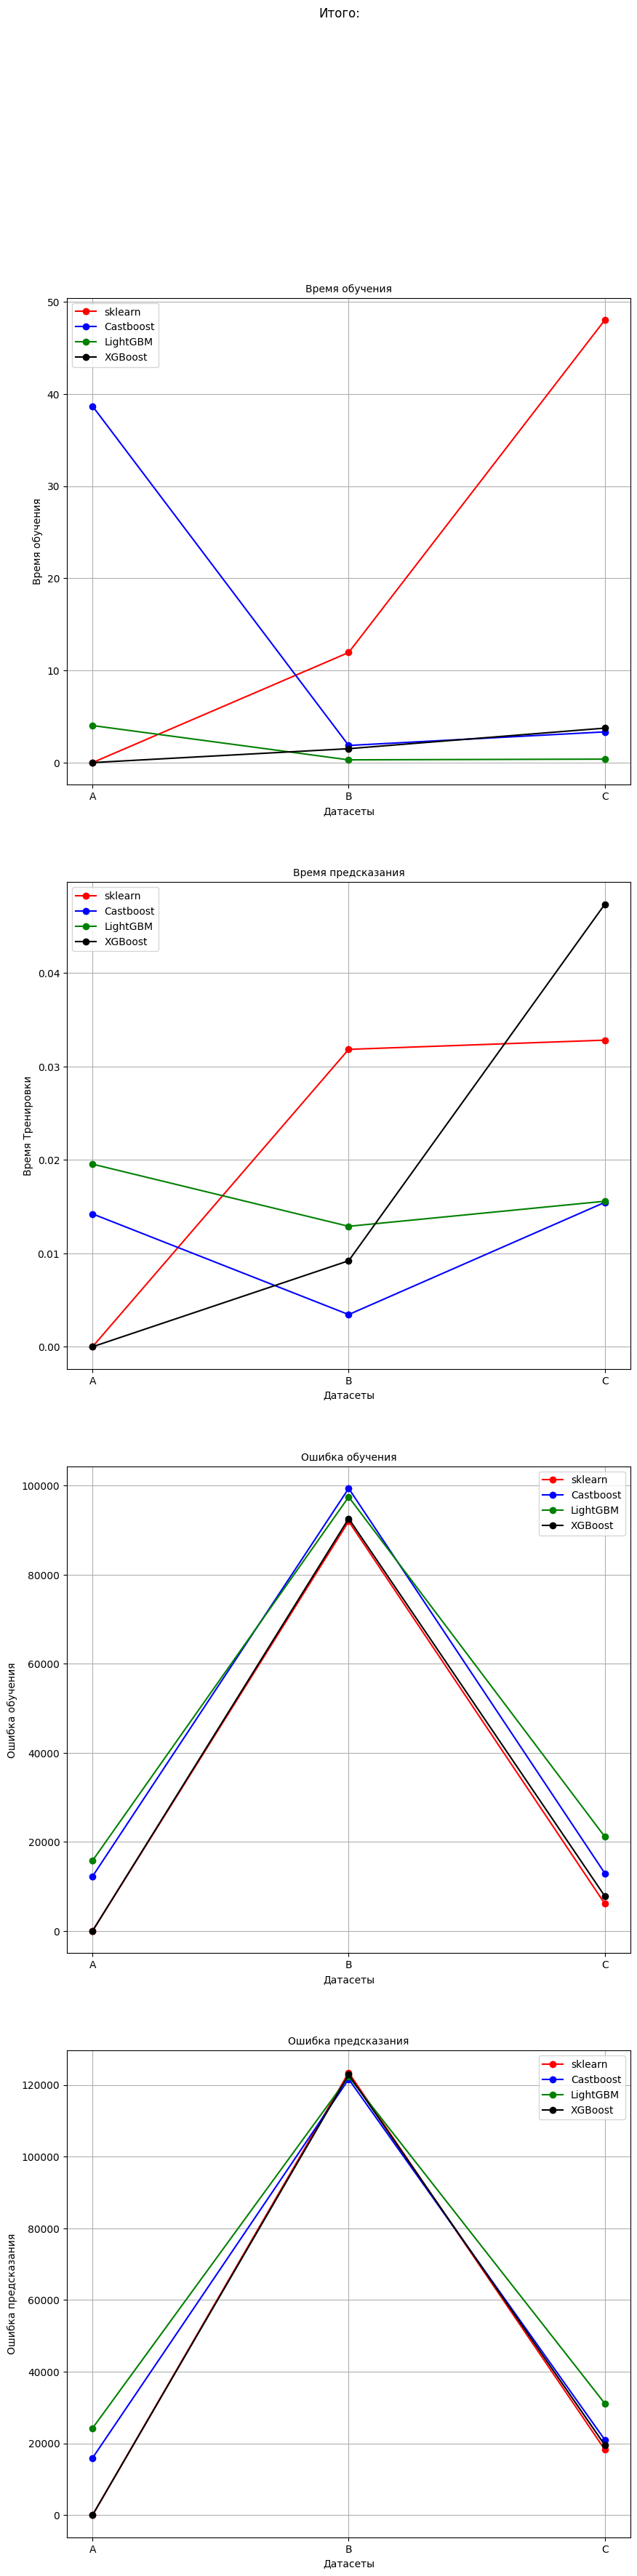

In [23]:
plt.figure(figsize=(10,40))

plt.suptitle('Итого:', fontsize=12)

plt.subplot(4, 1, 1)

plt.title('Время обучения',fontsize=10)

df_pivot_1 = df_other.pivot(columns='Dataset', index='library', values='Training time')
df_pivot_1 = df_pivot_1.fillna(0)
plt.plot(df_pivot_1.columns, df_pivot_1.loc['sklearn'], marker='o', color='red', label='sklearn')
plt.plot(df_pivot_1.columns, df_pivot_1.loc['Castboost'], marker='o', color='blue', label='Castboost')
plt.plot(df_pivot_1.columns, df_pivot_1.loc['LightGBM'], marker='o', color='green', label='LightGBM')
plt.plot(df_pivot_1.columns, df_pivot_1.loc['XGBoost'], marker='o', color='black', label='XGBoost')

plt.grid(True)

plt.ylabel('Время обучения',  fontsize=10)
plt.xlabel('Датасеты',  fontsize=10)

plt.legend(fontsize=10)





plt.subplot(4, 1, 2)

plt.title('Время предсказания',fontsize=10)

df_pivot_2 = df_other.pivot(columns='Dataset', index='library', values='Prediction time')
df_pivot_2 = df_pivot_2.fillna(0)
plt.plot(df_pivot_2.columns, df_pivot_2.loc['sklearn'], marker='o', color='red', label='sklearn')
plt.plot(df_pivot_2.columns, df_pivot_2.loc['Castboost'], marker='o', color='blue', label='Castboost')
plt.plot(df_pivot_2.columns, df_pivot_2.loc['LightGBM'], marker='o', color='green', label='LightGBM')
plt.plot(df_pivot_2.columns, df_pivot_2.loc['XGBoost'], marker='o', color='black', label='XGBoost')

plt.grid()

plt.ylabel('Время Тренировки',  fontsize=10)
plt.xlabel('Датасеты',  fontsize=10)

plt.legend(fontsize=10)



plt.subplot(4, 1, 3)

plt.title('Ошибка обучения',fontsize=10)

df_pivot_3 = df_other.pivot(columns='Dataset', index='library', values='Train MAE')
df_pivot_3 = df_pivot_3.fillna(0)
plt.plot(df_pivot_3.columns, df_pivot_3.loc['sklearn'], marker='o', color='red', label='sklearn')
plt.plot(df_pivot_3.columns, df_pivot_3.loc['Castboost'], marker='o', color='blue', label='Castboost')
plt.plot(df_pivot_3.columns, df_pivot_3.loc['LightGBM'], marker='o', color='green', label='LightGBM')
plt.plot(df_pivot_3.columns, df_pivot_3.loc['XGBoost'], marker='o', color='black', label='XGBoost')

plt.grid()

plt.ylabel('Ошибка обучения',  fontsize=10)
plt.xlabel('Датасеты',  fontsize=10)

plt.legend(fontsize=10)





plt.subplot(4, 1, 4)

plt.title('Ошибка предсказания',fontsize=10)

df_pivot_4 = df_other.pivot(columns='Dataset', index='library', values='Test MAE')
df_pivot_4 = df_pivot_4.fillna(0)
plt.plot(df_pivot_4.columns, df_pivot_4.loc['sklearn'], marker='o', color='red', label='sklearn')
plt.plot(df_pivot_4.columns, df_pivot_4.loc['Castboost'], marker='o', color='blue', label='Castboost')
plt.plot(df_pivot_4.columns, df_pivot_4.loc['LightGBM'], marker='o', color='green', label='LightGBM')
plt.plot(df_pivot_4.columns, df_pivot_4.loc['XGBoost'], marker='o', color='black', label='XGBoost')

plt.grid()

plt.ylabel('Ошибка предсказания',  fontsize=10)
plt.xlabel('Датасеты',  fontsize=10)

plt.legend(fontsize=10)


plt.show()

**<font color='MediumOrchid'>Ваши выводы:</font>**

sklearn обучается дольше всех, но MAE в среднем меньше всех. У LightGBM время обучения меньше всех, но MAE в среднем больше всех. У XGBoost ошибка чуть больше sklearn, а время чуть больше чем у LightGBM. У Catboost время обученияя чуть меньше, чем у sklearn, но MAE чуть меньше чем у LightGBM